![](../../images/header.png)

# Galaxy spectra

<h6>Authors : ChatGPT draft</h6>
<h6>Last Updated : April 3, 2026</h6>


An overview of the electromagnetic spectrum, atomic emission and absorption lines, and the measurement of galaxy spectra with the DESI focal plane, fibers, spectrographs, and CCDs.

In this notebook, we build from the basic physics of light to the practical question of how DESI measures spectra and what those spectra look like for several important DESI source classes. In particular, we will compare:

- **BGS** (Bright Galaxy Survey) galaxies
- **LRGs** (Luminous Red Galaxies)
- **quasars**
- **normal stars**

By the end of this notebook, you should be able to:

- describe where galaxy spectroscopy sits in the electromagnetic spectrum
- explain why atoms produce emission and absorption lines
- distinguish continuum light from spectral-line features
- explain how DESI measures spectra with fibers, spectrographs, and CCDs
- recognize the broad spectral differences among BGS galaxies, LRGs, quasars, and stars


## Preferred Backgrounds


While not necessary, the following background will help:

- basic familiarity with plots
- comfort reading simple equations
- a general idea of what galaxies and stars are
- some experience running Jupyter notebook cells


## Setup

Run the cell below to load the tools used in this notebook.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Optional plotting preference for notebooks
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.figsize"] = (10, 4)

def gaussian(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)



## 1. The electromagnetic spectrum

The electromagnetic spectrum includes all wavelengths of light, from long-wavelength **radio** waves to very short-wavelength **gamma rays**.

Different parts of the spectrum reveal different physics:

- **Radio:** cold gas, synchrotron emission, jets
- **Infrared:** dust and obscured star formation
- **Optical:** starlight and many strong atomic transitions
- **Ultraviolet:** hot stars and ionized gas
- **X-ray:** accreting black holes and hot plasma

For DESI, the most important region is the **optical to near-infrared**, because many useful features in stars, galaxies, and quasars fall there.


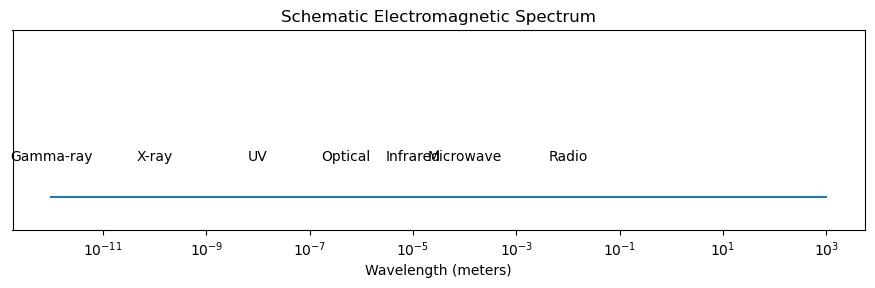

In [2]:

# A simple schematic of the electromagnetic spectrum

wavelength_m = np.logspace(-12, 3, 1000)

plt.figure(figsize=(11, 2.6))
plt.semilogx(wavelength_m, np.ones_like(wavelength_m))
plt.yticks([])
plt.xlabel("Wavelength (meters)")
plt.title("Schematic Electromagnetic Spectrum")

regions = [
    (1e-2, "Radio"),
    (1e-4, "Microwave"),
    (1e-5, "Infrared"),
    (5e-7, "Optical"),
    (1e-8, "UV"),
    (1e-10, "X-ray"),
    (1e-12, "Gamma-ray"),
]

for x, label in regions:
    plt.text(x, 1.002, label, ha="center", va="bottom")

plt.ylim(0.998, 1.01)
plt.show()



## 2. Continuum emission, emission lines, and absorption lines

A spectrum is a record of **flux versus wavelength**.

Most astronomical spectra contain two kinds of information:

### Continuum
The **continuum** is the broad smooth background shape of the spectrum.  
For galaxies, this often comes from the combined light of many stars.  
For quasars, it can be produced by the accretion disk around a black hole.

### Spectral lines
Superimposed on the continuum are narrow or broad features at special wavelengths:

- **absorption lines:** dips in the spectrum where light has been removed
- **emission lines:** peaks in the spectrum where extra light is produced

The continuum gives a broad view of the source, while the spectral lines tell us about specific atoms, ions, and physical conditions.



## 3. Why atoms make discrete lines

Atoms have quantized electron energy levels. Electrons can only jump between specific allowed states.

- When an atom **absorbs** a photon of the right energy, an electron jumps upward and creates an **absorption line**.
- When an electron drops downward and **emits** a photon, it creates an **emission line**.

Each element therefore has its own spectral fingerprint.

Common optical features include:

- Hydrogen Balmer lines such as H$\alpha$ and H$\beta$
- [O II] and [O III] emission from ionized gas
- Ca H and K absorption from stellar atmospheres
- Mg b absorption from older stellar populations


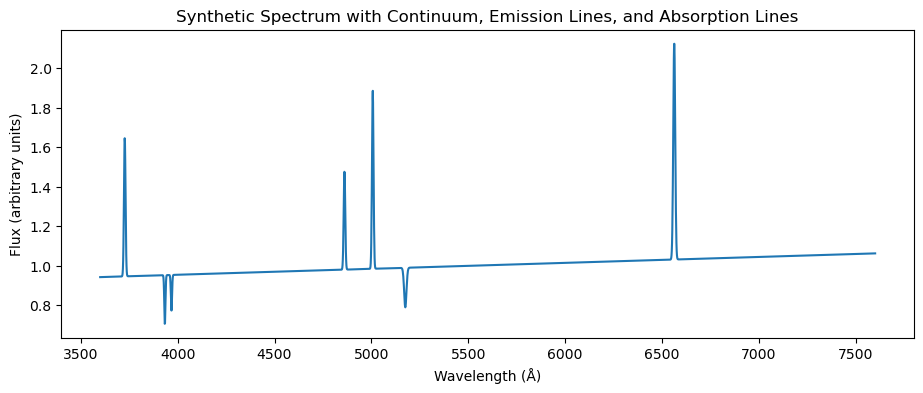

In [3]:

# Synthetic spectrum showing both emission and absorption features

w = np.linspace(3600, 7600, 3000)
continuum = 1.0 + 0.00003 * (w - 5500)
flux = continuum.copy()

# Emission lines
for mu, sig, amp in [(3727, 4, 0.7), (4861, 4, 0.5), (5007, 4, 0.9), (6563, 5, 1.1)]:
    flux += gaussian(w, mu, sig, amp)

# Absorption lines
for mu, sig, amp in [(3934, 3, 0.25), (3968, 3, 0.18), (5175, 6, 0.20)]:
    flux -= gaussian(w, mu, sig, amp)

plt.figure(figsize=(11, 4))
plt.plot(w, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (arbitrary units)")
plt.title("Synthetic Spectrum with Continuum, Emission Lines, and Absorption Lines")
plt.show()



## 4. Redshift

Because the universe is expanding, light from distant galaxies and quasars is shifted to longer wavelengths. This is called **redshift**.

\[
z = \frac{\lambda_{\mathrm{obs}} - \lambda_{\mathrm{rest}}}{\lambda_{\mathrm{rest}}}
\]

If you know the rest wavelength of a line and measure where it appears in the observed spectrum, you can estimate the redshift \(z\).

This is one of the main reasons galaxy spectroscopy is so powerful: it lets us build a three-dimensional map of the universe.


In [4]:

rest_line = 5007  # [O III] in Angstrom
for z in [0.0, 0.2, 0.5, 1.0]:
    observed = rest_line * (1 + z)
    print(f"z = {z:.1f} -> observed wavelength = {observed:.1f} Å")


z = 0.0 -> observed wavelength = 5007.0 Å
z = 0.2 -> observed wavelength = 6008.4 Å
z = 0.5 -> observed wavelength = 7510.5 Å
z = 1.0 -> observed wavelength = 10014.0 Å



## 5. How DESI measures spectra

DESI turns light from astronomical targets into calibrated spectra through a sequence of steps.

### 5.1 Focal plane
The telescope forms an image at the focal plane, where DESI places thousands of robotic fiber positioners.

### 5.2 Fibers
Each fiber is moved onto a target and captures its light from the sky.

### 5.3 Spectrographs
The fiber sends the light into a spectrograph, which disperses the light by wavelength.

### 5.4 CCDs
The dispersed light falls onto CCDs, where photons are recorded as pixel counts.

### 5.5 Extraction
The raw CCD image is processed into a one-dimensional spectrum: flux as a function of wavelength.

So the chain is:

**source on the sky → focal plane → fiber → spectrograph → CCD → extracted spectrum**


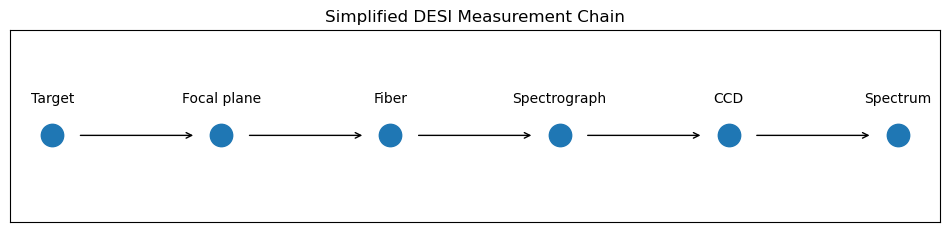

In [5]:

stages = ["Target", "Focal plane", "Fiber", "Spectrograph", "CCD", "Spectrum"]
x = np.arange(len(stages))

plt.figure(figsize=(12, 2.5))
plt.scatter(x, np.zeros_like(x), s=260)

for i, label in enumerate(stages):
    plt.text(i, 0.07, label, ha="center")

for i in range(len(stages) - 1):
    plt.annotate("", xy=(i + 0.85, 0), xytext=(i + 0.15, 0),
                 arrowprops=dict(arrowstyle="->"))

plt.xticks([])
plt.yticks([])
plt.ylim(-0.18, 0.22)
plt.title("Simplified DESI Measurement Chain")
plt.show()



## 6. Why different source classes have different spectra

Spectra differ because different objects are powered by different physical processes.

- A **star** shows the atmosphere of a single photosphere.
- A **galaxy** combines light from many stars, gas clouds, dust, and sometimes a black hole.
- A **quasar** is dominated by radiation from accretion onto a supermassive black hole.

That means different DESI targets can often be recognized directly from the pattern of continuum shape, line widths, and line strengths.



## 7. Spectral breakdown by target class

Below we focus on four broad classes:

1. **BGS galaxies**
2. **LRGs**
3. **quasars**
4. **normal stars**

These are not identical in every individual case, but they have characteristic patterns that are useful for first-pass interpretation.



### 7.1 BGS spectra

**BGS** stands for **Bright Galaxy Survey**. These are relatively bright, lower-redshift galaxies.

Typical spectral properties:

- a visible stellar continuum from the galaxy
- often a mix of **absorption lines** from stars and **emission lines** from gas
- many BGS objects are star-forming or mixed stellar-population galaxies
- common lines can include H$\alpha$, H$\beta$, [O II], [O III], and absorption features such as Ca H and K

A useful mental picture is that BGS spectra often look like **ordinary nearby galaxy spectra**: a continuum from stars plus varying amounts of nebular emission.



### 7.2 LRG spectra

**LRG** stands for **Luminous Red Galaxy**.

Typical spectral properties:

- a **red continuum**
- strong **absorption features**
- weak or absent nebular emission lines
- strong signatures of **old stellar populations**

LRGs are often dominated by older stars, so their spectra usually look smoother and redder than BGS star-forming spectra, with absorption features carrying much of the information.



### 7.3 Quasar spectra

Quasars are powered by accretion onto supermassive black holes.

Typical spectral properties:

- a bright continuum that can often be approximated as a power law
- very strong emission lines
- lines that are often **broad**, because gas near the black hole is moving rapidly
- at high redshift, strong ultraviolet lines are shifted into the optical

Quasar spectra usually look very different from normal galaxy spectra. Instead of a spectrum dominated by stellar absorption features, they are dominated by a bright active nucleus and strong emission lines.



### 7.4 Normal star spectra

A normal star spectrum is usually the light from a **single stellar photosphere**, not an entire galaxy.

Typical spectral properties:

- a smooth continuum that approximately follows a thermal shape
- many **narrow absorption lines**
- line patterns that depend strongly on temperature, composition, and gravity
- no galaxy redshift in the extragalactic sense, although stars can still have radial velocities

Stars are therefore useful as a comparison class: they often show lots of absorption structure but usually do **not** show the mixed galaxy-style pattern of stellar continuum plus nebular emission.


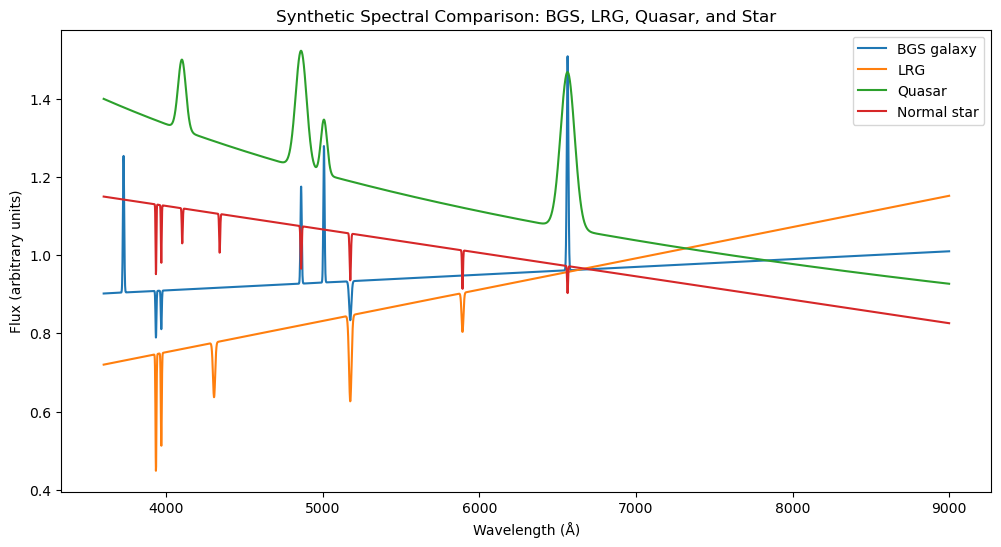

In [6]:

# Synthetic comparison spectra for BGS, LRG, quasar, and a normal star

w = np.linspace(3600, 9000, 4500)

def bgs_spectrum(w):
    f = 0.95 + 0.00002 * (w - 6000)
    # stellar absorption
    f -= gaussian(w, 3934, 3, 0.12)
    f -= gaussian(w, 3968, 3, 0.10)
    f -= gaussian(w, 5175, 7, 0.10)
    # nebular emission
    f += gaussian(w, 3727, 4, 0.35)
    f += gaussian(w, 4861, 4, 0.25)
    f += gaussian(w, 5007, 4, 0.35)
    f += gaussian(w, 6563, 5, 0.55)
    return f

def lrg_spectrum(w):
    f = 0.72 + 0.00008 * (w - 3600)
    f -= gaussian(w, 3934, 3, 0.30)
    f -= gaussian(w, 3968, 3, 0.24)
    f -= gaussian(w, 4305, 7, 0.14)
    f -= gaussian(w, 5175, 8, 0.22)
    f -= gaussian(w, 5892, 6, 0.10)
    return f

def quasar_spectrum(w):
    f = 1.4 * (w / 3600.0) ** (-0.45)
    # broad emission lines
    f += gaussian(w, 4100, 25, 0.18)
    f += gaussian(w, 4861, 35, 0.30)
    f += gaussian(w, 5007, 20, 0.14)
    f += gaussian(w, 6563, 45, 0.40)
    return f

def star_spectrum(w):
    # blackbody-like optical slope approximation for a normal star
    f = 1.15 - 0.00006 * (w - 3600)
    # many narrow absorption lines
    for mu, sig, amp in [
        (3934, 2.5, 0.18), (3968, 2.5, 0.15), (4102, 3.0, 0.09),
        (4341, 3.2, 0.10), (4861, 3.5, 0.11), (5175, 4.0, 0.12),
        (5892, 3.0, 0.10), (6563, 3.0, 0.07)
    ]:
        f -= gaussian(w, mu, sig, amp)
    return f

plt.figure(figsize=(12, 6))
plt.plot(w, bgs_spectrum(w), label="BGS galaxy")
plt.plot(w, lrg_spectrum(w), label="LRG")
plt.plot(w, quasar_spectrum(w), label="Quasar")
plt.plot(w, star_spectrum(w), label="Normal star")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (arbitrary units)")
plt.title("Synthetic Spectral Comparison: BGS, LRG, Quasar, and Star")
plt.legend()
plt.show()



## 8. Reading the comparison plot

Here is a simple way to distinguish the classes:

### BGS
Look for a galaxy-like continuum with a combination of stellar absorption and moderate emission lines.

### LRG
Look for a red continuum and strong absorption features, with very little emission.

### Quasar
Look for a bright non-stellar continuum and strong broad emission lines.

### Star
Look for a smooth stellar continuum with many narrow absorption features and no obvious galaxy-like nebular emission pattern.



## 9. Summary table

| Class | Continuum | Emission lines | Absorption lines | Physical picture |
|---|---|---|---|---|
| BGS | stellar galaxy continuum | often present, sometimes strong | present | bright nearby galaxies with mixed stellar and gas signatures |
| LRG | red continuum | weak or absent | strong | old stellar populations dominate |
| Quasar | bright active continuum | strong, often broad | can be present but not dominant | accreting supermassive black hole |
| Normal star | stellar photosphere continuum | usually weak/absent in this context | many narrow lines | light from a single star |



## 10. Why this matters for DESI

DESI uses spectra to do several things at once:

- determine whether a target is a **galaxy**, **quasar**, or **star**
- measure the **redshift** of galaxies and quasars
- separate different target classes for cosmology analyses
- build a three-dimensional map of large-scale structure

That means the science depends both on the **physics of spectral features** and on the **instrument chain** that measures them.



## 11. Practice questions

1. Why do atoms produce lines only at specific wavelengths?
2. What is the main visual difference between an LRG spectrum and a quasar spectrum?
3. Why might a BGS spectrum show both absorption and emission lines?
4. Why do stellar spectra often contain many narrow absorption features?
5. What role do DESI fibers play in the measurement process?
6. Why is a CCD image not yet the final scientific spectrum?



### Conclusion

You have now worked through a tutorial connecting the physics of light to DESI spectroscopy.

To review:

- the electromagnetic spectrum gives us multiple windows into astrophysical objects
- atomic transitions create emission and absorption lines
- DESI measures spectra using its focal plane, fibers, spectrographs, and CCDs
- BGS, LRG, quasar, and stellar spectra differ because they arise from different physical sources
- those differences help DESI classify objects and measure redshifts

![](../../images/footer.png)
